#**Machine learning - Insurance Charges Prediction**

##Insurance dataset description:
1. **age:** Age of the individual in years, impacts insurance risk calculation
2. **sex:** Gender of individual, male or female, influences health risk patterns
3. **bmi:** Body mass index measuring body fat based on height weight
4. **children:** Number of dependents covered under insurance plan, affects overall cost
5. **smoker:** Indicates whether person smokes, significantly increases insurance charges risk
6. **region:** Geographical residential area, influences healthcare costs and insurance pricing variations
7. **charges:** Total medical insurance cost billed to individual, target prediction variable

###**Steps of Machine Learning**
1. Problem Statement
2. Data Collection
3. Data PreProcessing
4. EDA
5. Feature Enginering
6. Model Traning
7. Model Selection
8. Model Evluation
9. Model Deployment
10. Maintainance / Update

## **Importing library**

In [ ]:
import numpy as np                  # statistics computation
import pandas as pd                 # data analysis
import matplotlib.pyplot as plt     # data visulization
import seaborn as sns               # advance data visulization

import warnings
warnings.filterwarnings('ignore')

## **Loading dataset**

In [ ]:
df = pd.read_csv('/content/insurance.csv')

In [ ]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## **Data PreProcessing**
1. Check the dataset structure, columns, and basic statistics; identify missing values.

2. Handle missing data, transform data types, and manage outliers.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## **EDA - Exploratary Data Analysis**
Analyze summary statistics, correlations, and identify trends or issues.

In [ ]:
df.rename(columns={"sex": "gender"}, inplace=True)

In [ ]:
numeric_col = ["age",	'bmi',	"children"	,"charges"]

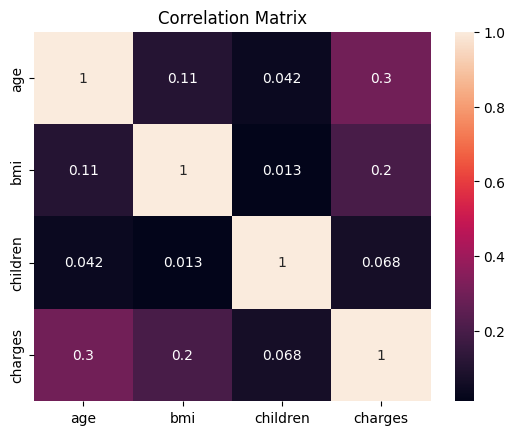

In [ ]:
corr = df[numeric_col].corr()

sns.heatmap(corr, annot = True)

plt.title("Correlation Matrix")
plt.show()

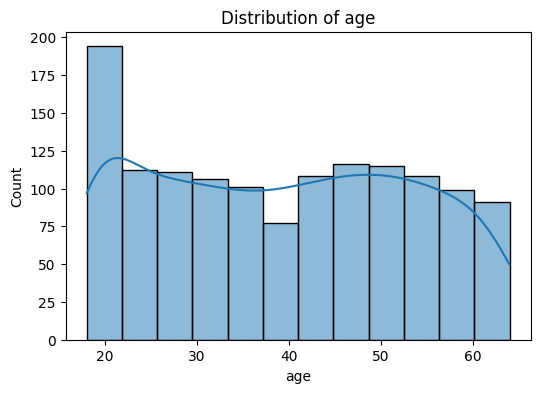

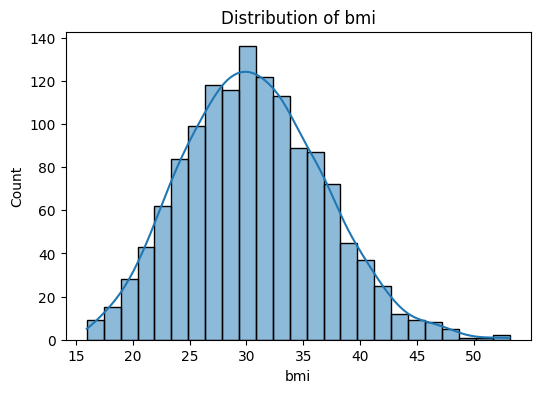

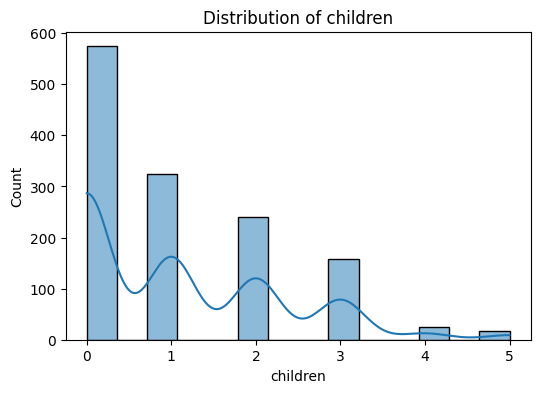

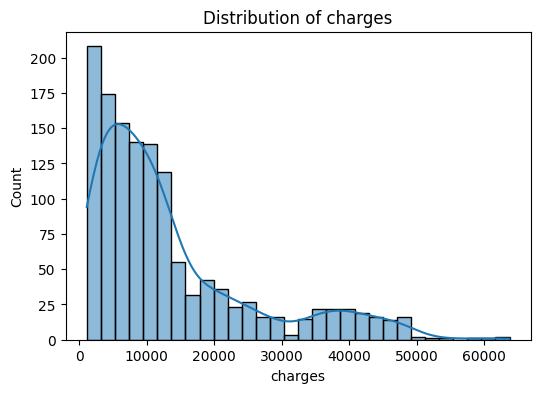

In [ ]:
for col in numeric_col:
  plt.figure(figsize=(6,4))

  sns.histplot(df[col], kde = True)
  plt.title(f"Distribution of {col}")
  plt.show()

### **Insights:**
1. **Age:** Most people are between **20–60 years** and evenly distributed with slightly **more younger adults**.
2. **BMI:** Most BMI values lie between **25–35** with a **normal bell-shaped distribution** around **30**.
3. **Children:** Most people have **0–2 children**, and **higher numbers** are increasingly rare.
4. **Charges:** Most **insurance charges** are below **15,000**, with a few very high values creating a **right-skewed distribution**.

In [ ]:
# Number of counts between male and female
df["gender"].value_counts()

,count
gender,
male,676
female,662


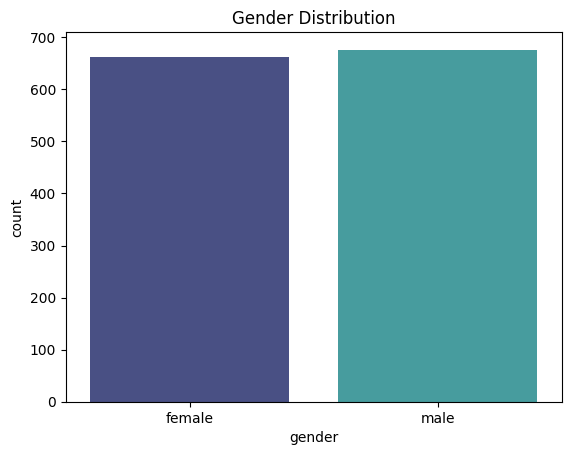

In [ ]:
sns.countplot(x='gender', data=df, palette='mako')

plt.title("Gender Distribution")
plt.show()

In [ ]:
# Number of counts between smoker (yes) and non smoker (no)
df["smoker"].value_counts()

,count
smoker,
no,1064
yes,274


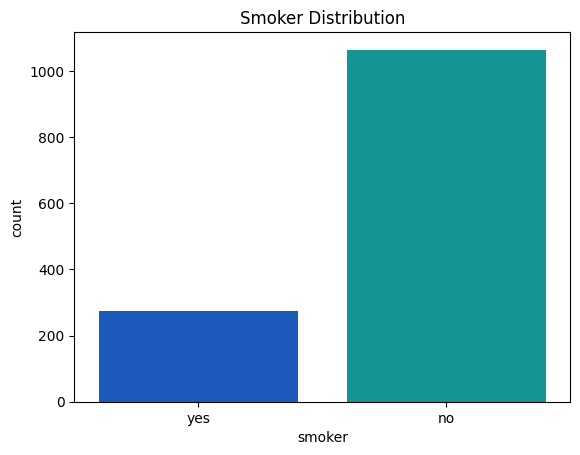

In [ ]:
sns.countplot(x = df['smoker'],  data=df, palette='winter')

plt.title("Smoker Distribution")
plt.show()

###**Insights:**
1. **Age** has a **moderate positive correlation** with **charges (~0.30)**.
2. **BMI** shows a **weak positive relationship** with **charges (~0.20)**.
3. **Children** have very **low impact** on **insurance charges (~0.06)**.
4. **Independent variables** have low **inter-correlation**, **reducing multicollinearity risk**.

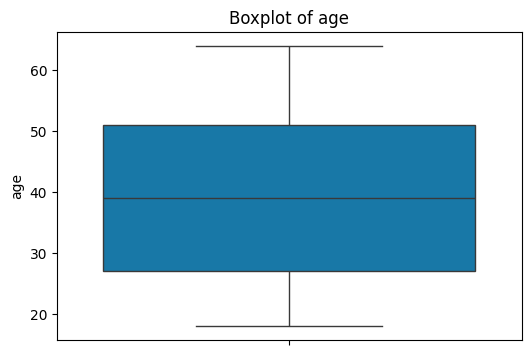

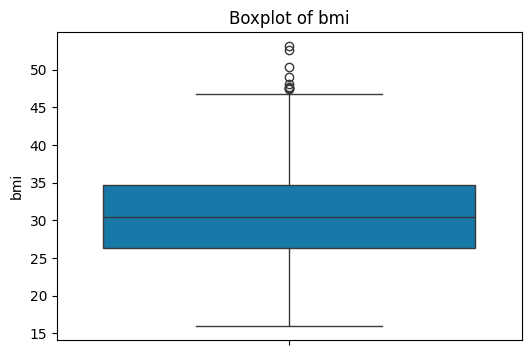

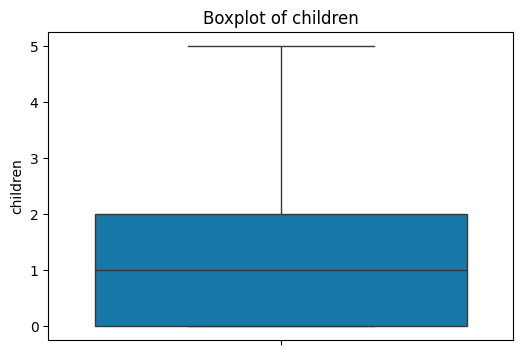

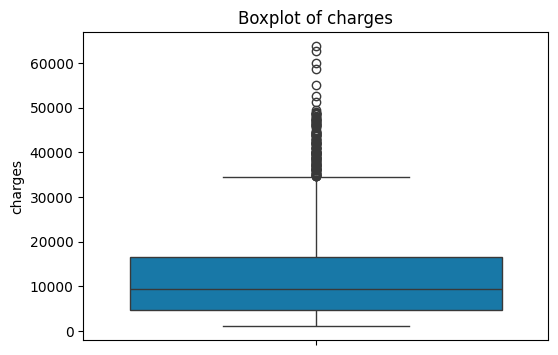

In [ ]:
for box in numeric_col:
  plt.figure(figsize=(6,4))

  sns.boxplot(df[box], palette='winter')

  plt.title(f"Boxplot of {box}")
  plt.show()

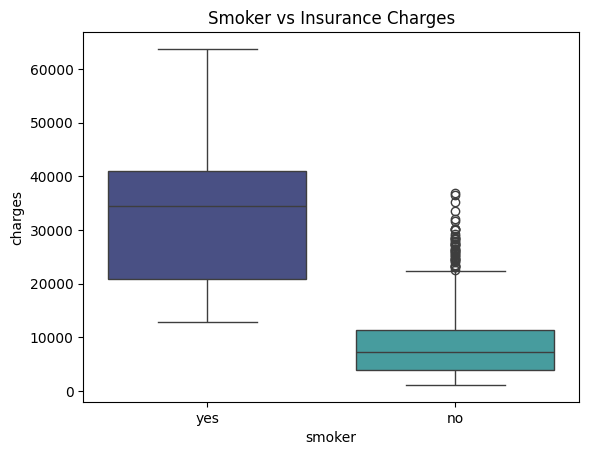

In [ ]:
sns.boxplot(data = df , x = "smoker", y = "charges", palette='mako')

plt.title("Smoker vs Insurance Charges")
plt.show()

### **Insights:**
1. **Smokers** have **significantly higher median charges** compared to **non-smokers**.
2. The spread **(IQR)** for **smokers is much wider**, indicating higher variability.
3. **Non-smokers** mostly have **lower** and **tightly clustered charges**.
4. Presence of **outliers** shows **extreme high costs**, especially among **smokers**.

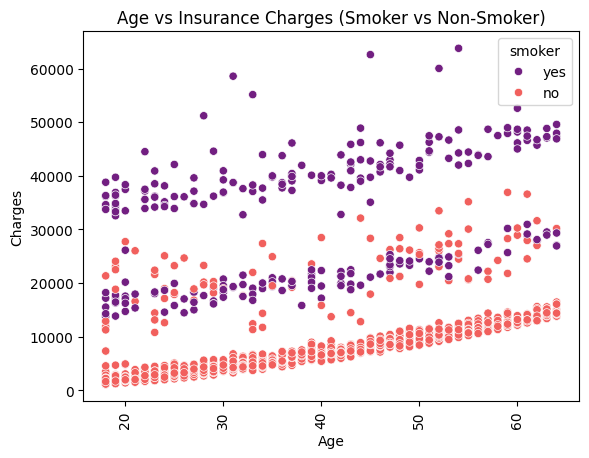

In [ ]:
# Plotting of Age vs Charges using Scatter plotting
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", palette='magma')

plt.xticks(rotation=90)   # rotate 90 degree angle
plt.title("Age vs Insurance Charges (Smoker vs Non-Smoker)")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

### **Insights:**
1. Insurance **charges increase as age increases** for both **smokers and non-smokers**.
2. Smokers pay much higher charges than non-smokers at the same age.
3. Non-smokers have lower and more consistent insurance costs.
4. The **highest insurance charges** are mostly for **older smokers**.

##**Infrenatial Stastics**
Inferential Statistics is the branch of statistics that helps us make predictions or decisions about a population based on a sample of data.

Check Null Hypothesis is assumption is true or not:

1. p-value < 0.05 → Significant (Reject Null Hypothesis)

2. p-value ≥ 0.05 → Not Significant (Fail to Reject)

In [ ]:
import scipy.stats as stats

In [ ]:
corr , p_value = stats.pearsonr(df['age'], df['charges'])

In [ ]:
print("corr", corr)
print("p-value", p_value)

corr 0.29900819333064754
p-value 4.886693331718529e-29


In [ ]:
df_cleaned = df.copy()

In [ ]:
df_cleaned

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Feature Engineering**

Feature Engineering is the process of transforming raw data into meaningful inputs that help your machine learning model make better predictions.

## **Feature Encoding**

Converting text-based data (like "male/female" or "smoker/non-smoker") into numbers so the mathematical equations.

**1. Label Encoding**

Label encoding in feature engineering is a technique used to convert categorical values into numeric labels.

Example: Gender -> Male = 0 & Female = 1

In [ ]:
# label encoding

df_cleaned["gender"] = df_cleaned["gender"].map({"male": 0, "female":1})
df_cleaned["smoker"] = df_cleaned["smoker"].map({"yes": 1, "no":0})

In [ ]:
# rename column name
df_cleaned.rename(columns= {"gender" : "is_female", "smoker" : "is_smoker"}, inplace = True)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,northwest,10600.54830
1334,18,1,31.920,0,0,northeast,2205.98080
1335,18,1,36.850,0,0,southeast,1629.83350
1336,21,1,25.800,0,0,southwest,2007.94500


###**2. One Hot Encoding**

1. Assign a unique number of catrgories.
2. When we usage have oder or priority(odinal data - has order).

   Eg: Gender = is_male , is_female

In [ ]:
# one hot encoding - expand columns into multiple columns

df_cleaned = (pd.get_dummies(df_cleaned, columns=["region"]))

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,False,True
1,18,0,33.770,1,0,1725.55230,False,False,True,False
2,28,0,33.000,3,0,4449.46200,False,False,True,False
3,33,0,22.705,0,0,21984.47061,False,True,False,False
4,32,0,28.880,0,0,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,False,True,False,False
1334,18,1,31.920,0,0,2205.98080,True,False,False,False
1335,18,1,36.850,0,0,1629.83350,False,False,True,False
1336,21,1,25.800,0,0,2007.94500,False,False,False,True


In [ ]:
# convert data type change True and False into 0 and 1
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,0,1
1,18,0,33,1,0,1725,0,0,1,0
2,28,0,33,3,0,4449,0,0,1,0
3,33,0,22,0,0,21984,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0
1334,18,1,31,0,0,2205,1,0,0,0
1335,18,1,36,0,0,1629,0,0,1,0
1336,21,1,25,0,0,2007,0,0,0,1


##**Feature Creation**

Generating new variables from existing ones to highlight specific patterns.

Example: BMI = 27

Create New Column -> BMI Category = underweight, normal, overweight, obese

In [ ]:
df_cleaned["bmi_category"] = pd.cut(df_cleaned["bmi"], bins =[0, 18.5, 24.9, 29.9, float('inf')],
                                    labels = ["underweight", "normal", "overweight", "obese"])

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,0,1,overweight
1,18,0,33,1,0,1725,0,0,1,0,obese
2,28,0,33,3,0,4449,0,0,1,0,obese
3,33,0,22,0,0,21984,0,1,0,0,normal
4,32,0,28,0,0,3866,0,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,obese
1334,18,1,31,0,0,2205,1,0,0,0,obese
1335,18,1,36,0,0,1629,0,0,1,0,obese
1336,21,1,25,0,0,2007,0,0,0,1,overweight


In [ ]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ["bmi_category"])

In [ ]:
df_cleaned = df_cleaned.astype(int)

In [ ]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,0,1,0,0,0,0,0,1
1334,18,1,31,0,0,2205,1,0,0,0,0,0,0,1
1335,18,1,36,0,0,1629,0,0,1,0,0,0,0,1
1336,21,1,25,0,0,2007,0,0,0,1,0,0,1,0


## **Feature Scaling**
Rescaling numerical features to a similar range (0 and 1) for better model learning.

In [ ]:
df_norml = df_cleaned.copy()

In [ ]:
# normalization
col_to_scale = ["age", "children"]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_n = MinMaxScaler()

df_norml[col_to_scale] = scaler_n.fit_transform(df_norml[col_to_scale])

In [ ]:
df_norml.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,0.021739,1,27,0.0,1,16884,0,0,0,1,0,0,1,0
1,0.000000,0,33,0.2,0,1725,0,0,1,0,0,0,0,1
2,0.217391,0,33,0.6,0,4449,0,0,1,0,0,0,0,1
3,0.326087,0,22,0.0,0,21984,0,1,0,0,0,1,0,0
4,0.304348,0,28,0.0,0,3866,0,1,0,0,0,0,1,0


In [ ]:
from scipy.stats import pearsonr

# list to check feature columns(independent variable) against target value(dependent variable)
col_list = ["age", "bmi", "children", "is_female", "is_smoker", "region_northeast", "region_northwest", "region_southeast", "region_southwest", "bmi_category_normal", "bmi_category_obese", "bmi_category_overweight", "bmi_category_underweight"]

correlations = {
    feature : pearsonr(df_norml[feature], df_norml["charges"])[0]
    for feature in col_list
    }

In [ ]:
correlations_df = pd.DataFrame(list(correlations.items()), columns = ["feature", "correlation"])

correlations_df.sort_values(by = "correlation", ascending = False, inplace = True)

In [ ]:
correlations_df

,feature,correlation
4,is_smoker,0.787251
0,age,0.299009
10,bmi_category_obese,0.199533
1,bmi,0.196188
7,region_southeast,0.073981
2,children,0.067999
5,region_northeast,0.006350
6,region_northwest,-0.039905
8,region_southwest,-0.043210
12,bmi_category_underweight,-0.050484


### **Final Feature Selection:**
1. Selected **age, bmi, children** as key numerical features influencing medical risk and cost.
2. Included **is_smoker** due to its **strong impact on insurance charges**.
3. Added **region variables** to capture geographical cost variations in **healthcare**.
4. Used **bmi_category_obese** to highlight **high-risk** individuals with elevated BMI.
5. Chose features based on correlation, relevance, and model performance improvement.

In [ ]:
final_df = df_norml[["age", "children", "is_smoker", "charges", "region_southeast", "bmi_category_obese","region_northeast", "is_female"]]

In [ ]:
final_df

,age,children,is_smoker,charges,region_southeast,bmi_category_obese,region_northeast,is_female
0,0.021739,0.0,1,16884,0,0,0,1
1,0.000000,0.2,0,1725,1,1,0,0
2,0.217391,0.6,0,4449,1,1,0,0
3,0.326087,0.0,0,21984,0,0,0,0
4,0.304348,0.0,0,3866,0,0,0,0
...,...,...,...,...,...,...,...,...
1333,0.695652,0.6,0,10600,0,1,0,0
1334,0.000000,0.0,0,2205,0,1,1,1
1335,0.000000,0.0,0,1629,1,1,0,1
1336,0.065217,0.0,0,2007,0,0,0,1


In [ ]:
# 8 feature columns and 1 target column
final_df.shape

(1338, 8)

## **Model Traning**
Teaching the model using training data to learn patterns.

In [ ]:
from sklearn.model_selection import train_test_split

**Defining Features (X):**
1. Created by dropping charges column from dataset.
2. Contains independent variables like age, bmi, children, smoker, region.
3. Used as input data for model to make predictions.


**Defining Target (y):**
1. Created by selecting charges column only.
2. Use depedent variable or target value.
3. Used as output variable the model tries to predict.

In [ ]:
X = final_df.drop("charges", axis = 1)
y = final_df["charges"]

In [ ]:
X

,age,children,is_smoker,region_southeast,bmi_category_obese,region_northeast,is_female
0,0.021739,0.0,1,0,0,0,1
1,0.000000,0.2,0,1,1,0,0
2,0.217391,0.6,0,1,1,0,0
3,0.326087,0.0,0,0,0,0,0
4,0.304348,0.0,0,0,0,0,0
...,...,...,...,...,...,...,...
1333,0.695652,0.6,0,0,1,0,0
1334,0.000000,0.0,0,0,1,1,1
1335,0.000000,0.0,0,1,1,0,1
1336,0.065217,0.0,0,0,0,0,1


In [ ]:
y

,charges
0,16884
1,1725
2,4449
3,21984
4,3866
...,...
1333,10600
1334,2205
1335,1629
1336,2007


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

##**Model Selection**
Choosing the best algorithm based on performance.

##**Linear regression**
1. Linear regression is one of the most fundamental algorithms in machine learning and statistics.

2. It forms the backbone of more advanced models and is essential for understanding how learning systems optimize themselves using gradient-based methods.

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)  # Train Data

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)   # y_pred with input of X_test

In [ ]:
y_pred = y_pred.astype(int)

In [ ]:
y_pred

array([ 8416,  9031, 35569,  8492, 28217,  8906,   272, 16288,  3188,
        9271, 27950, 11131,  3569, 36743, 39156, 36595, 13514, 36201,
        7983, 30116,  3854, 11650,  4604,  5975,  9543, 14284, 15263,
        7916,  8936,  4638,  7354, 14484,  5430,  4350,  6829, 11934,
        1199,  6911, 32860, 33332,  2308,  5790, 14631, 10645,  9347,
       11052,  5951,  3052, 35964,  8828, 16335,   700, 10477,   579,
       14505, 14047,  3694, 32555, 14743, 14024, 16041,  8581, 16731,
        7059, 13764,  3016, 26020, 10343,  2237,  5383, 10524, 13021,
       12440, 10905, 11796,  4979,  8482,  9879,  8062,  8245,  5157,
       35616,  4462, 30662, 29697, 36845,  8976, 13952, 11663, 14654,
       17175, 35862, 32141,  4769, 32553, 11131, 27948,  5170, 27963,
        5820,  3535,   272, 10610, 15433, 11744,  5045, 12203, 32993,
         579, 33414,  4604,  7122, 15730, 33111, 13393,  5271, 11484,
       30931, 10399,  1705,  9498, 11131, 14579,  6196,  3423, 11144,
       11549,  9035,

In [ ]:
y_test

,charges
764,9095
887,5272
890,29330
1293,9301
259,33750
...,...
109,47055
575,12222
535,6067
543,63770


##**Model Evaluation**
Measuring how well the model performs on unseen data.

In [ ]:
# check model performance
from sklearn.metrics import r2_score, mean_squared_error
mse = mean_squared_error(y_test, y_pred)  # y_test = 20%, y_pred
r2 = r2_score(y_test, y_pred)

print(f"Mean Sqaured Error: {mse}")
print(f"R2 Score: {r2}")

Mean Sqaured Error: 34451132.186567165
R2 Score: 0.7780902847014304


In [ ]:
# Adj r^2
n = X_test.shape[0]
k = X_test.shape[1]

adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
print("Adjusted R-squared:", adj_r2)

Adjusted R-squared: 0.7721157923664689


##**Conclusion - Train Data**
1. The model achieved an **R² of ~0.778**, explaining about **77.8%** of the variance in insurance charges.
2. Adjusted **R² (~0.772) is close to R²**, indicating the selected features are meaningful.
3. MSE **(~34.45M)** reflects **prediction error** and is **high due to large charge values**.
4. Overall, the model provides **reasonably accurate predictions** performance could improve with feature engineering or more advanced models.

###**Note:**
---
Train Data = 80% (X_train, y_train)

Test Data = 20% (X_test, y_test)

Predict Data = y_predict with X_test(input)

In [ ]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,bmi_category_underweight,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,0,1,0,0,1,0
1,18,0,33,1,0,1725,0,0,1,0,0,0,0,1
2,28,0,33,3,0,4449,0,0,1,0,0,0,0,1
3,33,0,22,0,0,21984,0,1,0,0,0,1,0,0
4,32,0,28,0,0,3866,0,1,0,0,0,0,1,0


In [ ]:
col_s = ["age", "children"]

In [ ]:
# new data predection
import pandas as pd

# Example new user input
new_data = {
    'age': 19, 'children': 0, 'is_smoker': 1, 'region_southeast':0,
       'bmi_category_obese':0, 'region_northeast':0, 'is_female': 1
    }

new_df = pd.DataFrame([new_data])

In [ ]:
# Apply normalization
new_df[col_s] = scaler_n.transform(new_df[col_s])

In [ ]:
prediction = model.predict(new_df)

print("Prediction of Insurance Charges:", prediction[0])

Prediction of Insurance Charges: 23885.181733528054


##**Conclusion - New Data**
1. The model was tested using new input data and successfully generated a prediction.
2. For similar feature values, the **actual charge in the dataset was 16,884**, while the model predicted **approximately 23,885** for the new input.
3. The difference between actual and predicted values is expected due to model estimation error and feature influence.
4. Overall, the model provides reasonable predictions and can be used to estimate insurance charges for unseen data.